### 1. Import Libraries and Load Data

In [1]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset


dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\Ahmed Almoor\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2. Group the Skills by Month

In [2]:
df_analyst = df[df['job_title_short'] == 'Data Analyst'].copy()


df_analyst['job_posted_month_no'] = df_analyst['job_posted_date'].dt.strftime('%m')


df_skills = df_analyst.copy()
df_skills['job_skills'] = df_skills['job_skills'].apply(lambda x: x if isinstance(x, list) else [])
df_skills_exploded = df_skills.explode('job_skills')


df_skills_count = (
    df_skills_exploded.groupby(['job_posted_month_no', 'job_skills'])
    .size()
    .reset_index(name='skill_count')
)

### 3. Pivot in Prepration for Plotting

In [3]:
df_skills_pivot = df_skills_count.pivot(index='job_posted_month_no', columns='job_skills', values='skill_count')
df_skills_pivot = df_skills_pivot.fillna(0)

### 4. Sort Columns by Count and Change Month Names to Numbers

In [4]:

df_skills_pivot = df_skills_pivot[df_skills_pivot.sum().sort_values(ascending=False).index]

df_skills_pivot = df_skills_pivot.reset_index()
df_skills_pivot['job_posted_month'] = pd.to_datetime(df_skills_pivot['job_posted_month_no'], format='%m').dt.strftime('%b')
df_skills_pivot = df_skills_pivot.set_index('job_posted_month')
df_skills_pivot = df_skills_pivot.drop(columns='job_posted_month_no')

### 5. Plot Monthly Skill Counts

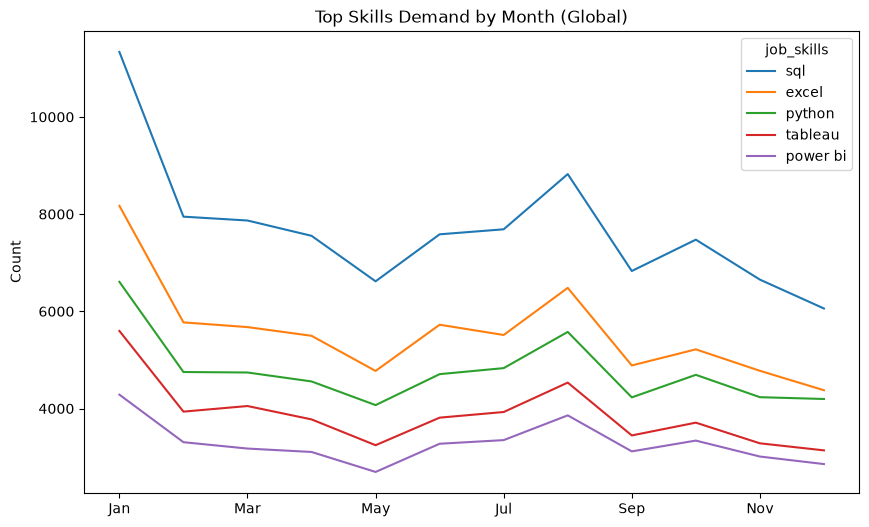

In [5]:

fig, ax = plt.subplots(figsize=(10, 6))

df_skills_pivot.iloc[:, :5].plot(kind='line', ax=ax)

ax.set_title('Top Skills Demand by Month (Global)')
ax.set_ylabel('Count')
ax.set_xlabel('')
plt.show()

### 6. Calculate Percentage of Total Jobs

In [6]:

df_job_count = df_analyst['job_title_short'].value_counts().reset_index() 

df_total_jobs = df_analyst.groupby('job_posted_month_no').size().reset_index(name='jobs_total')


df_skills_pivot_percent = df_skills_pivot.reset_index()

df_skills_pivot_percent['job_posted_month_no'] = pd.to_datetime(df_skills_pivot_percent['job_posted_month'], format='%b').dt.strftime('%m')

df_skills_pivot_percent = pd.merge(df_skills_pivot_percent, df_total_jobs, on='job_posted_month_no', how='left')


for col in df_skills_pivot.columns:
    df_skills_pivot_percent[col] = (df_skills_pivot_percent[col] / df_skills_pivot_percent['jobs_total']) * 100


df_skills_pivot_percent = df_skills_pivot_percent.set_index('job_posted_month')
df_skills_pivot_percent = df_skills_pivot_percent.drop(columns=['job_posted_month_no', 'jobs_total'])

### 7. Plot Monthly Skill Demand

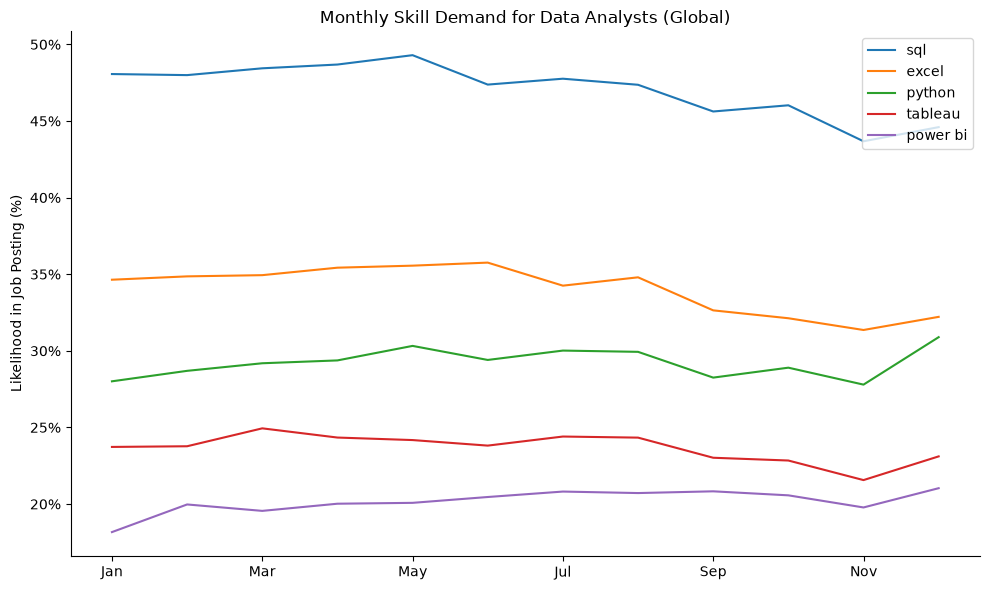

In [7]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10, 6))


df_skills_pivot_percent.iloc[:, :5].plot(kind='line', ax=ax)

ax.set_title('Monthly Skill Demand for Data Analysts (Global)')
ax.set_ylabel('Likelihood in Job Posting (%)')
ax.set_xlabel('')


ax.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))


sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()